In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 5
def operator_A(N):
    A = np.ones((N, N))
    for j in range(N):
        for i in range(N):
            A[j,i] /= (i + 1) + (j + 1) - 1
    return A
x = np.ones((N))

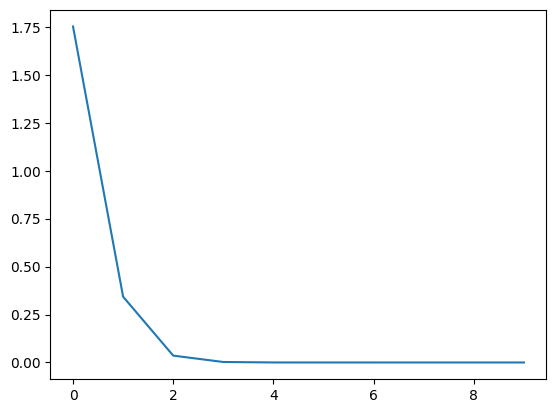

In [470]:
A = operator_A(10)
eig_values, eig_vector = np.linalg.eig(A)
eig_values
plt.plot(eig_values)

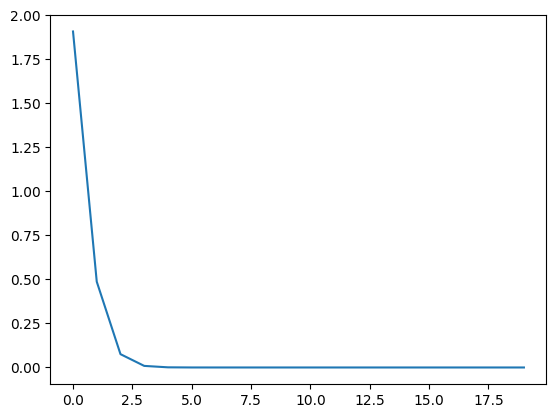

In [471]:
A = operator_A(20)
eig_values, eig_vector = np.linalg.eig(A)
eig_values
plt.plot(eig_values)

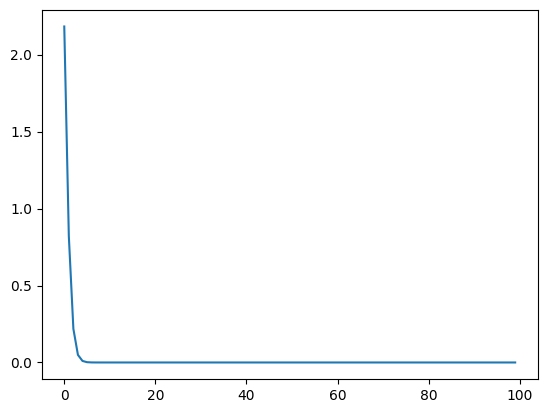

In [472]:
A = operator_A(100)
eig_values, eig_vector = np.linalg.eig(A)
eig_values
plt.plot(eig_values)

Решить систему с зашумленной правой частью

In [473]:
def residual(x1:float, x2:float): # невязка
  return np.abs(x1 - x2)

def seydel(A,B,eps=1e-9):
    # Метод Зейделя
    # начальные значения
    n = len(A)
    x = [0 for i in range(n)]           # Вектор X{0, 0, ..., 0}
    count_iter = 0                      # счетчик

    # Итерации м.Зейделя
    while(True):
        for i in range(n):
            sum = 0
            for j in range(n):
                if (i != j):
                    sum = sum - A[i][j] * x[j]
            sum = sum + B[i]
            sum = sum / A[i][i]

            if(residual(x[i], sum) < eps):  # Если невязка |x_текущая-x_предыдущая| < eps выходим из цикла и возвращаем x
                print("Число итераций:", count_iter)
                return x

            if(count_iter > 10000 or residual(x[i], sum) > 10**5):
                count_iter = 0
                return x

            x[i] = sum
            count_iter += 1

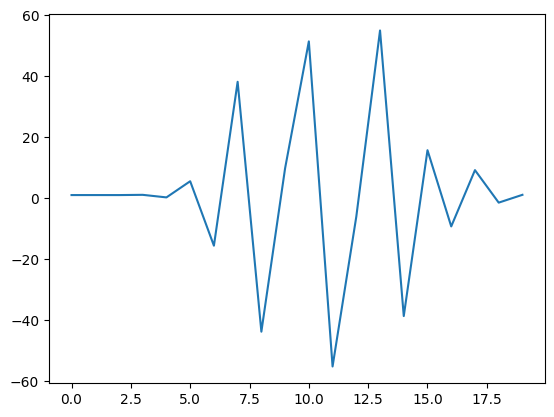

In [474]:
#Ax = b 
N = 20
delta = 0.05

A = operator_A(N)
b = np.zeros(N)
for i in range(N):
    sumA = 0
    for j in range(N):
        sumA += A[i][j]
    b[i] = sumA 

x = np.linspace(0,1,N)
sigma_ = 1.0
sigma = np.exp(-((x-0.5)/1.0)**2/2)

b_delta = b + delta * sigma

y = np.linalg.solve(A, b)
#plt.plot(sigma)
plt.plot(y)

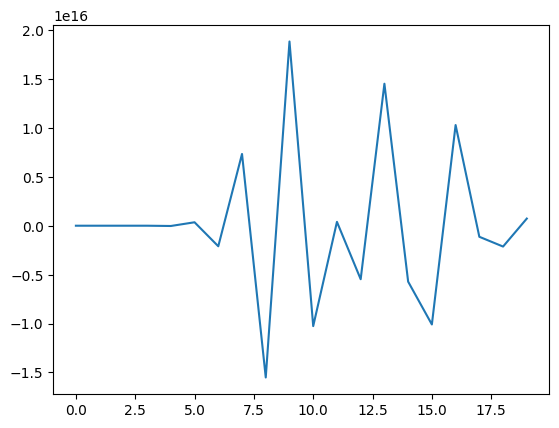

In [475]:
#Ax = b 
N = 20
delta = 0.05

A = operator_A(N)
b = np.zeros(N)
for i in range(N):
    sumA = 0
    for j in range(N):
        sumA += A[i][j]
    b[i] = sumA 

# = np.linspace(0,1,N)
sigma = np.random.normal(size=N)

b_delta = b + delta * sigma

y = np.linalg.solve(A, b_delta)
plt.plot(y)

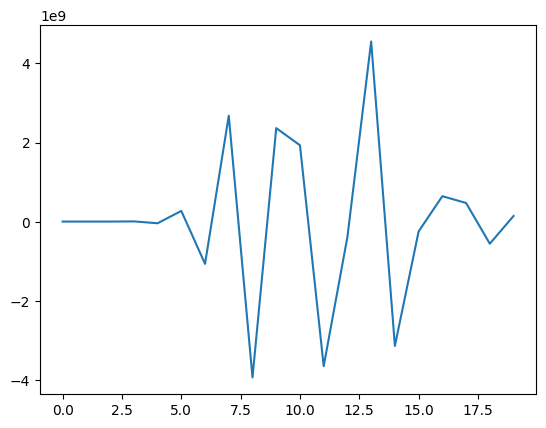

In [476]:
#Ax = b 
N = 20
delta = 0.05

A = operator_A(N)
b = np.zeros(N)
for i in range(N):
    sumA = 0
    for j in range(N):
        sumA += A[i][j]
    b[i] = sumA 

x = np.linspace(0,1,N)
sigma_ = 1.0
sigma = np.exp(-((x-0.5)/1.0)**2/2)

b_delta = b + delta * sigma

y = np.linalg.solve(A, b_delta)
plt.plot(y)

Решить систему с помощью регуляризации Тихонова

[0.88665456 1.10220405 1.13383857 1.13963185 1.13072639 1.11200905
 1.08712455 1.05867972 1.02844831 0.99760129 0.96689468 0.93680503
 0.90762246 0.87951332 0.85256223 0.82680007 0.80222289 0.77880454
 0.75650515 0.73527696]
norm B 0.017118682803194337


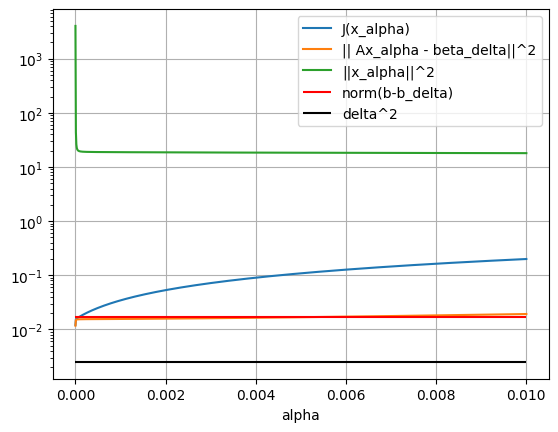

In [477]:
#Ax = b 
N = 20
delta = 0.05

A = operator_A(N)
b = np.zeros(N)
for i in range(N):
    sumA = 0
    for j in range(N):
        sumA += A[i][j]
    b[i] = sumA 

#x = np.linspace(0,1,N)
sigma = np.random.rand(N)*2-1

b_delta = b + delta * sigma
def J(A, b_delta, x , alpha):
    return np.linalg.norm(np.matmul(A,x) - b_delta)**2 + alpha * np.linalg.norm(x)**2

E = np.zeros((N,N))
for i in range(N):
    E[i,i] = 1
M = 1000
alphas = np.linspace(1e-7, 1e-2, M)
Jx_alpha = np.zeros(M)
residuals = np.zeros(M)
x_alphas = np.zeros(M)
i = 0
# A.T @ A + alpha @ np.eye(N) 
for alpha in alphas:
    #u = #np.matmul(np.linalg.inv(np.matmul(A.T, A) + alpha * E), np.matmul(A.T, b_delta))
    ATA = A.T @ A
    ATb = A.T @ b_delta
    I = np.eye(N)
    u = np.linalg.solve(ATA + alpha * I, ATb)
    Jx_alpha[i] = J(A, b_delta, u, alpha)
    residuals[i] = np.linalg.norm(np.matmul(A,u) - b_delta)**2
    x_alphas[i] = np.linalg.norm(u)**2
    
    i += 1
plt.plot(alphas, Jx_alpha,  label="J(x_alpha)")
plt.plot(alphas, residuals, label="|| Ax_alpha - beta_delta||^2")
plt.plot(alphas, x_alphas, label="||x_alpha||^2")
plt.xlabel('alpha')
plt.hlines(np.linalg.norm(b - b_delta)**2, alphas[0], alphas[-1], colors='red',label='norm(b-b_delta)')
plt.hlines(delta**2,alphas[0], alphas[-1], colors='black', label='delta^2')
plt.yscale('log')
plt.legend()
plt.grid()
alpha = 0.002
u = np.matmul(np.linalg.inv(np.matmul(A.T, A) + alpha * E), np.matmul(A.T, b_delta))
print(u)
print("norm B", np.linalg.norm(b - b_delta)**2)

[0.88665456 1.10220405 1.13383857 1.13963185 1.13072639 1.11200905
 1.08712455 1.05867972 1.02844831 0.99760129 0.96689468 0.93680503
 0.90762246 0.87951332 0.85256223 0.82680007 0.80222289 0.77880454
 0.75650515 0.73527696]


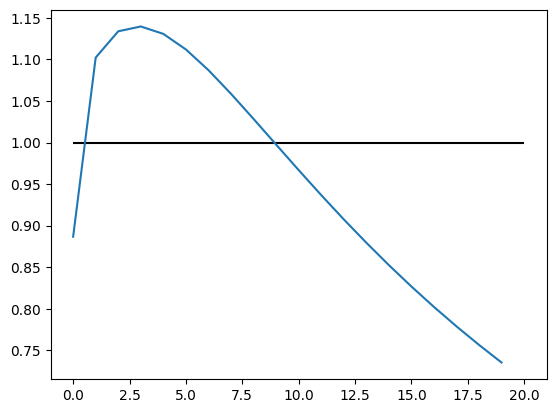

In [478]:
alpha = 0.002
ATA = A.T @ A
ATb = A.T @ b_delta
I = np.eye(N)
u = np.linalg.solve(ATA + alpha * I, ATb)

plt.hlines(1, 0, 20, colors='black')
print(u)
plt.plot(u)


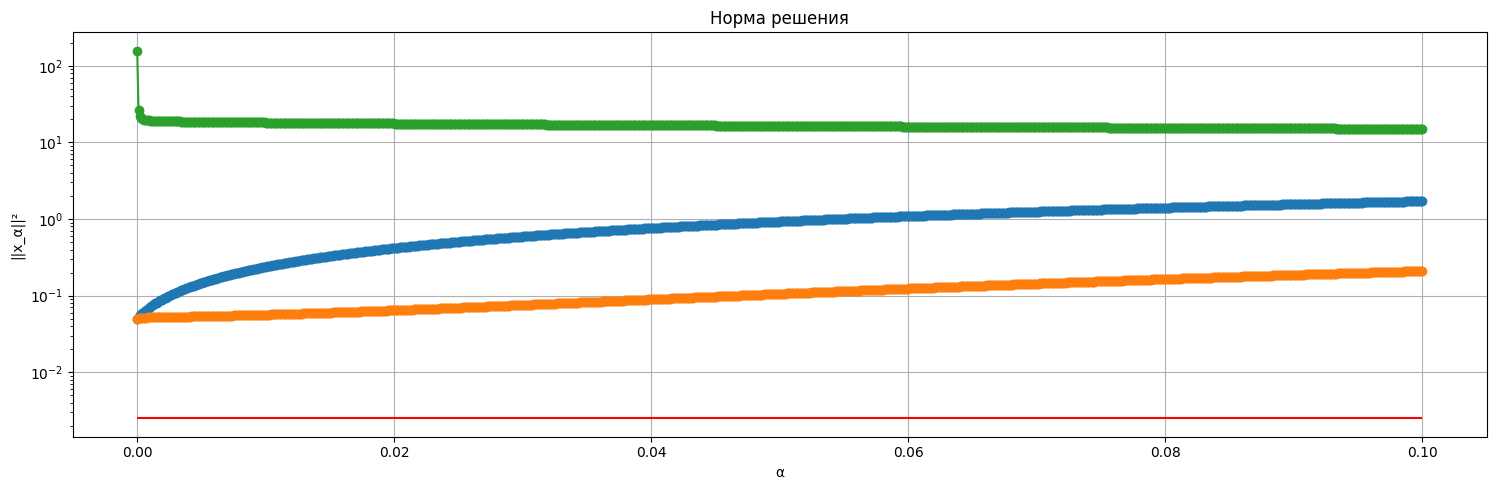

In [479]:
import numpy as np
import matplotlib.pyplot as plt

# Входные данные
N = 20
delta = 0.05

A = operator_A(N)
b = np.zeros(N)
for i in range(N):
    sumA = 0
    for j in range(N):
        sumA += A[i][j]
    b[i] = sumA 

#x = np.linspace(0,1,N)
sigma = np.random.normal(size=N)

b_delta = b + delta * sigma
M = 1000
alphas = np.linspace(1e-7, 1e-1, M)
# Списки для хранения результатов
J_values = []
residuals = []
norms = []

# Решение для каждого alpha
for alpha in alphas:
    ATA = A.T @ A
    ATb = A.T @ b_delta
    I = np.eye(N)
    x_alpha = np.linalg.solve(ATA + alpha * I, ATb)
    
    # Вычисления
    residual = A @ x_alpha - b_delta
    residual_norm = np.sum(residual**2)
    x_norm = np.sum(x_alpha**2)
    J = residual_norm + alpha * x_norm
    
    # Сохранение
    J_values.append(J)
    residuals.append(residual_norm)
    norms.append(x_norm)

# Графики
plt.figure(figsize=(15, 5))

plt.plot(alphas, J_values, 'o-')
plt.xlabel('α')
plt.ylabel('J(x_α)')
plt.title('Функционал J(x_α)')
plt.grid(True)


plt.plot(alphas, residuals, 'o-')
plt.xlabel('α')
plt.ylabel('||Ax_α - b_δ||²')
plt.title('Невязка')
plt.grid(True)


plt.plot(alphas, norms, 'o-')
plt.xlabel('α')
plt.ylabel('||x_α||²')
plt.title('Норма решения')
plt.grid(True)
plt.hlines(delta**2, alphas[0], alphas[-1], colors='red')
plt.tight_layout()
plt.yscale('log')
plt.show()

[1.16534972 0.47179869 0.95852138 1.23128597 1.33511402 1.34606014
 1.30943324 1.24988098 1.18065945 1.10888212 1.03831947 0.97089754
 0.90751449 0.84849447 0.79384429 0.74340044 0.69691395 0.65409939
 0.61466287 0.57831766]


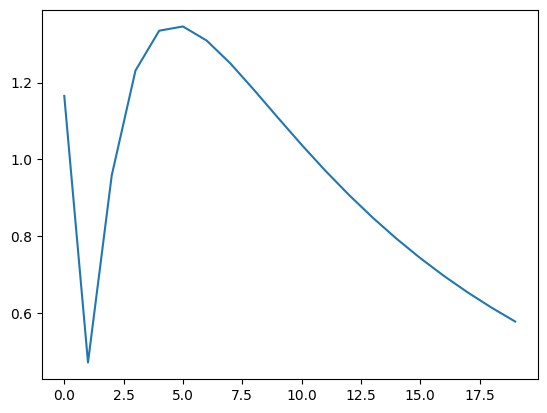

In [480]:
alpha = 0.0005
ATA = A.T @ A
ATb = A.T @ b_delta
I = np.eye(N)
x_alpha = np.linalg.solve(ATA + alpha * I, ATb)
print(x_alpha)
plt.plot(x_alpha)